# Pacotes

In [1]:
import os
import sys
import yaml
import pandas as pd
import seaborn as sns
current_dir = os.path.dirname(os.path.abspath('.'))
project_root = os.path.abspath(os.path.join(current_dir, "../.."))
sys.path.insert(0, project_root)

from functions.feature_selection import FeatureSelectionOrchestrator
from utils.plots import Pearson_correlation, Bar_plot, plot_numerical_data
from Regression.house_prices.src.features.feat_eng_pipeline import PreprocessingOrchestrator
import matplotlib.pyplot as plt
plt.style.use('ggplot')

In [2]:
import warnings
warnings.filterwarnings('ignore')

# Config

In [3]:
with open(os.path.join("../config/config.yaml"), "r") as f:
    config = yaml.safe_load(f)
        
with open(os.path.join( "../config/pipeline.yaml"), "r") as f:
    config_pipe = yaml.safe_load(f)  

# Load dataset

In [4]:
X_train = pd.read_parquet(
        os.path.join(
            config['init_path'],
            config['data']['processed'],
            "train_features.parquet")
    )
y_train = X_train[config_pipe['features']['pipeline1']['target'][0]]

# Features analysis

## Apply Pipeline

In [5]:
preprocessor = PreprocessingOrchestrator(
    numerical_con_1=config_pipe['features']['pipeline1']['num_con_1'],
    numerical_con_2=config_pipe['features']['pipeline1']['num_con_2'],
    numerical_dis=config_pipe['features']['pipeline1']['num_dis_1'],
    categorical_var=config_pipe['features']['pipeline1']['cat_var']
    )
pipe = preprocessor.apply("pipeline1")    
X_train_trans = pipe.fit_transform(X_train)

In [6]:
X_train_trans

,num_con_1_pipe__LotArea,num_con_1_pipe__TotalBsmtSF,num_con_1_pipe__GrLivArea,num_con_2_pipe__MasVnrArea,num_con_2_pipe__BsmtFinSF1,num_con_2_pipe__2ndFlrSF,num_con_2_pipe__WoodDeckSF,num_con_2_pipe__OpenPorchSF,num_con_2_pipe__GarageArea,num_con_2_pipe__BsmtUnfSF,...,categorical_pipe__ExterQual,categorical_pipe__Foundation,categorical_pipe__BsmtQual,categorical_pipe__BsmtCond,categorical_pipe__BsmtExposure,categorical_pipe__CentralAir,categorical_pipe__KitchenQual,categorical_pipe__GarageFinish,categorical_pipe__SaleType,categorical_pipe__SaleCondition
0,9.041922,6.753438,7.444249,7,7,8,0,6,8,6,...,Gd,PConc,Gd,TA,No,Y,Gd,RFn,WD,Normal
1,9.169518,7.141245,7.140453,0,7,0,8,0,8,7,...,TA,CBlock,Gd,TA,Rare,Y,TA,RFn,WD,Normal
2,9.328123,6.825460,7.487734,6,7,8,0,5,8,7,...,Gd,PConc,Gd,TA,Rare,Y,Gd,RFn,WD,Normal
3,9.164296,6.629363,7.448334,0,6,8,0,5,8,8,...,TA,BrkTil,TA,Rare,No,Y,Gd,Unf,WD,Rare
4,9.565214,7.044033,7.695303,7,7,9,7,7,9,7,...,Gd,PConc,Gd,TA,Av,Y,Gd,RFn,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,8.976768,6.860664,7.406711,0,0,8,0,5,8,8,...,TA,PConc,Gd,TA,No,Y,TA,RFn,WD,Normal
1456,9.486076,7.341484,7.636752,6,7,0,8,0,8,8,...,TA,CBlock,Gd,TA,No,Y,TA,Unf,WD,Normal
1457,9.109636,7.050123,7.757906,0,6,9,0,6,7,8,...,Rare,Rare,TA,Rare,No,Y,Gd,RFn,WD,Normal
1458,9.181632,6.983790,6.982863,0,4,0,8,0,7,0,...,TA,CBlock,TA,TA,Rare,Y,Gd,Unf,WD,Normal


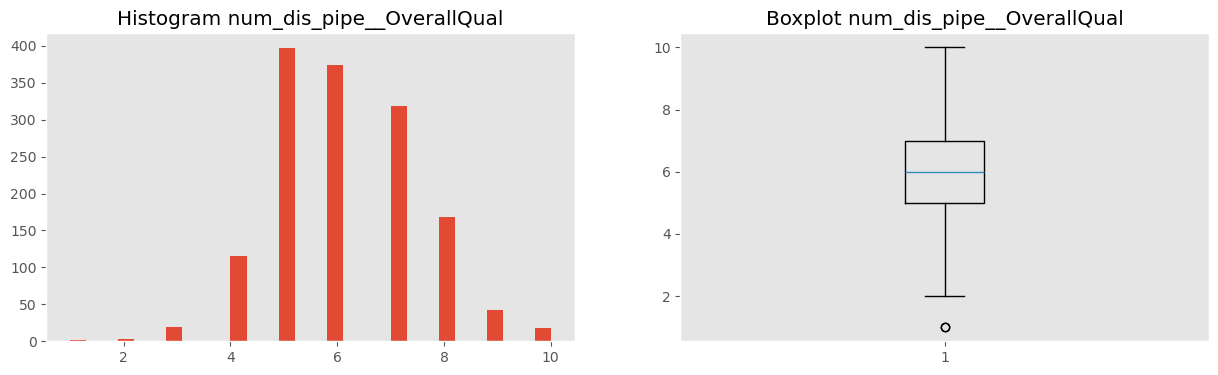

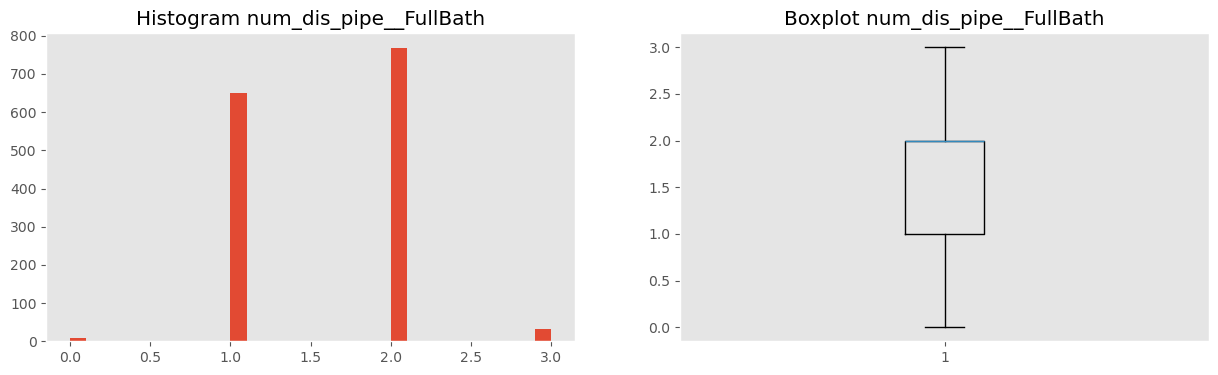

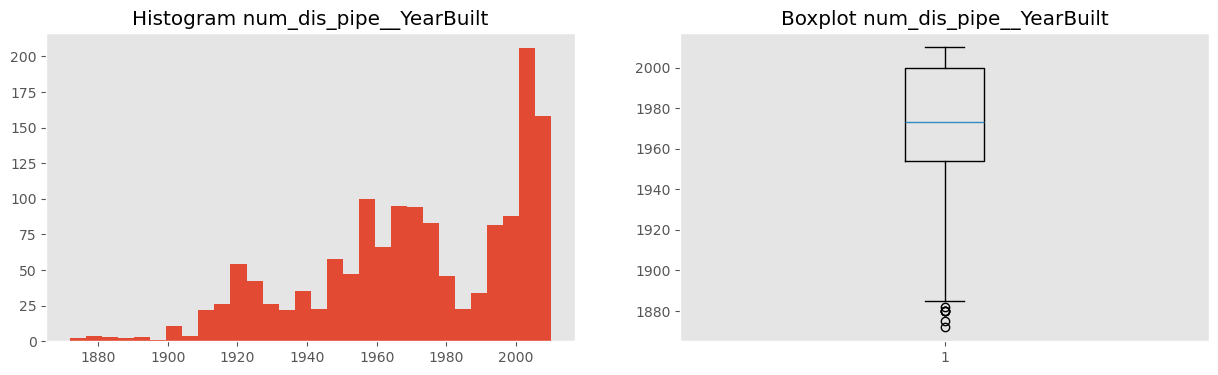

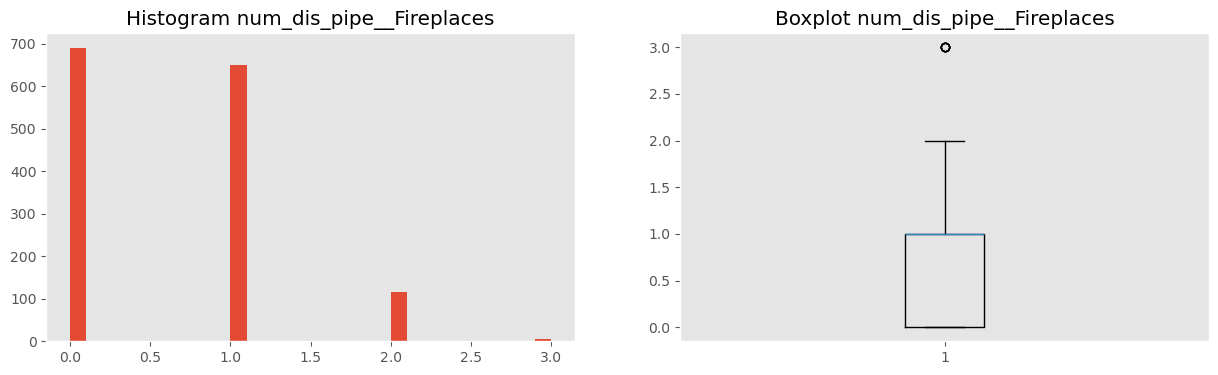

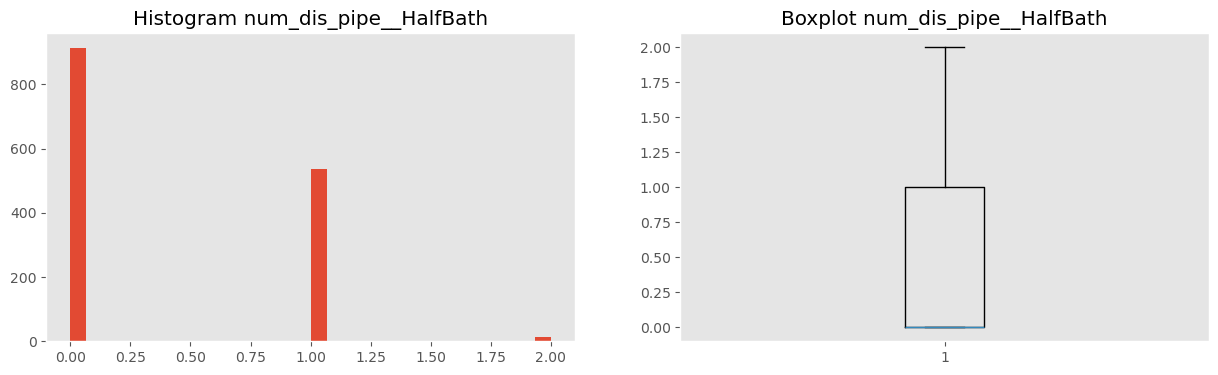

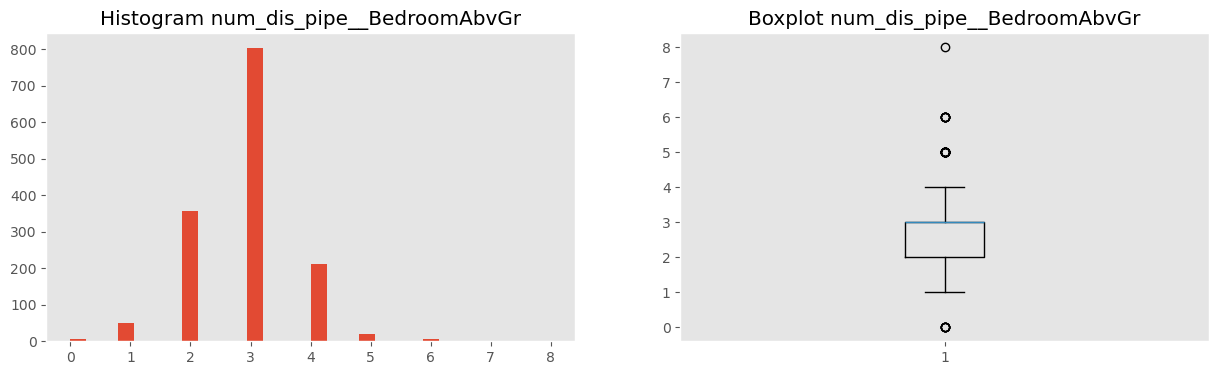

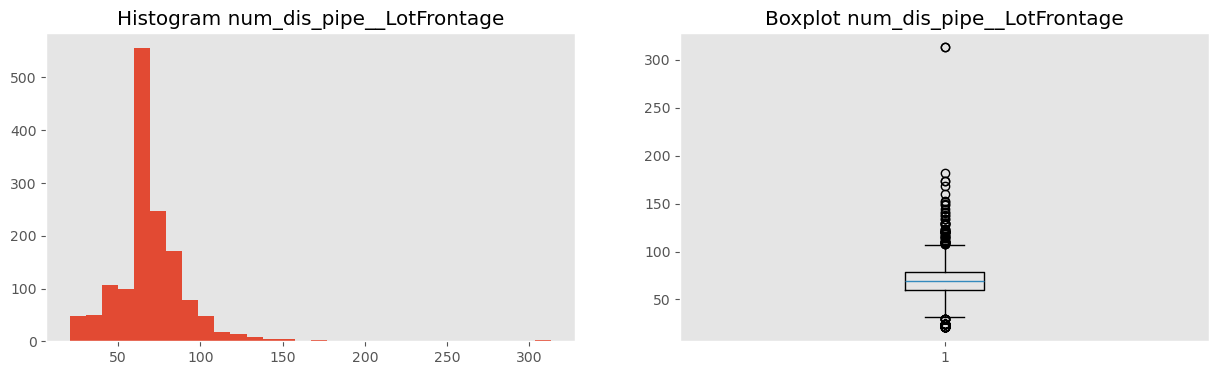

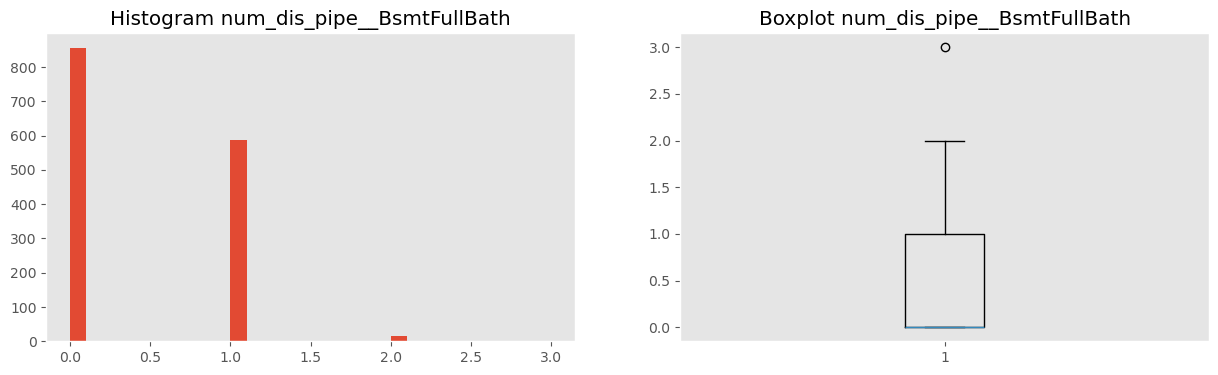

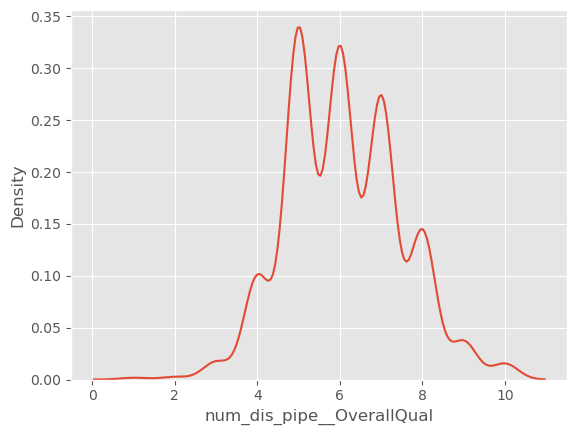

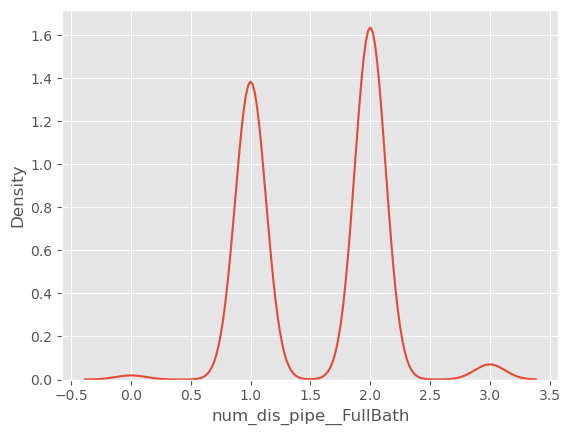

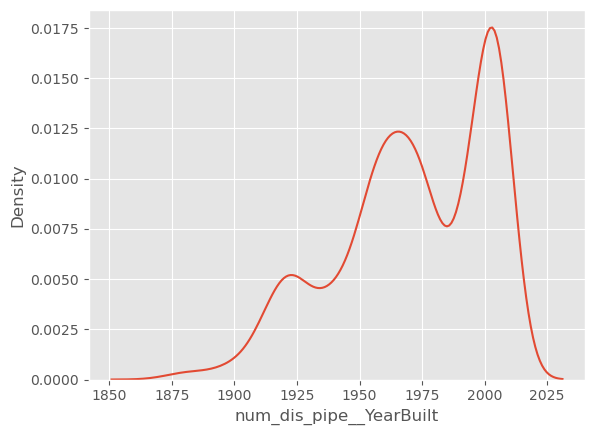

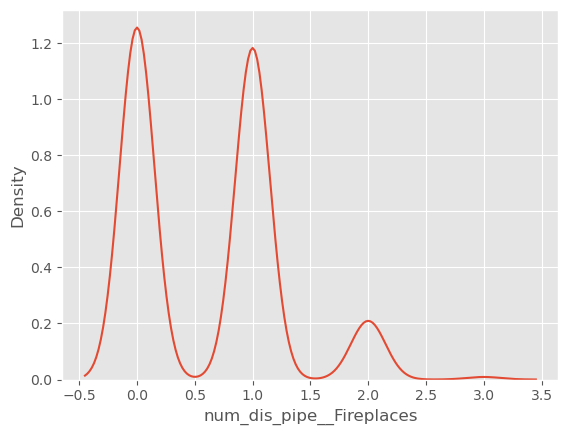

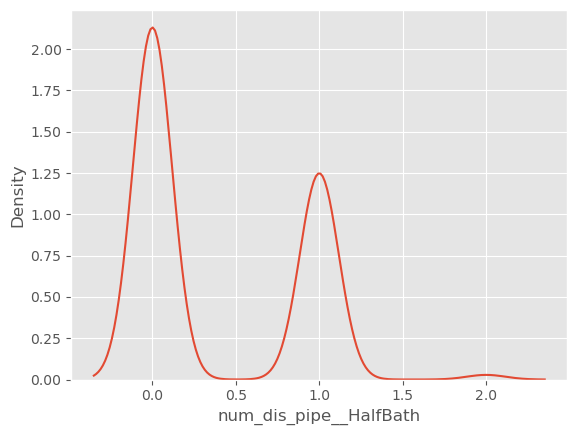

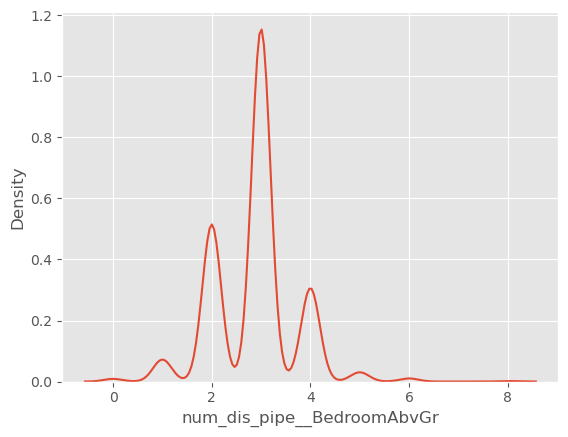

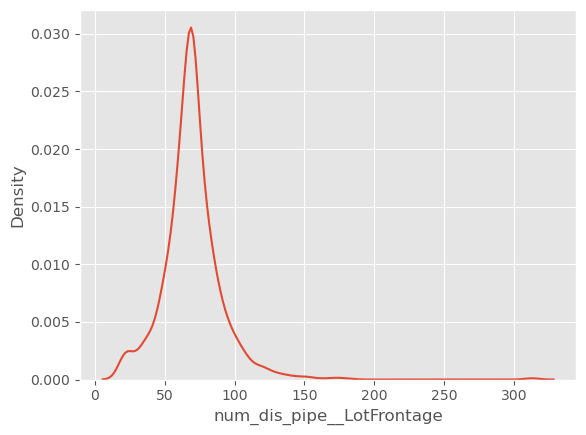

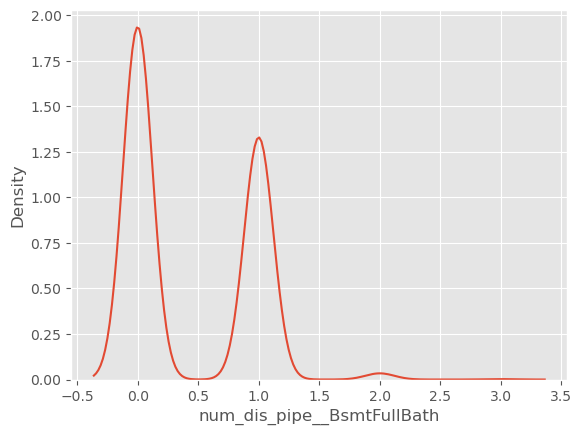

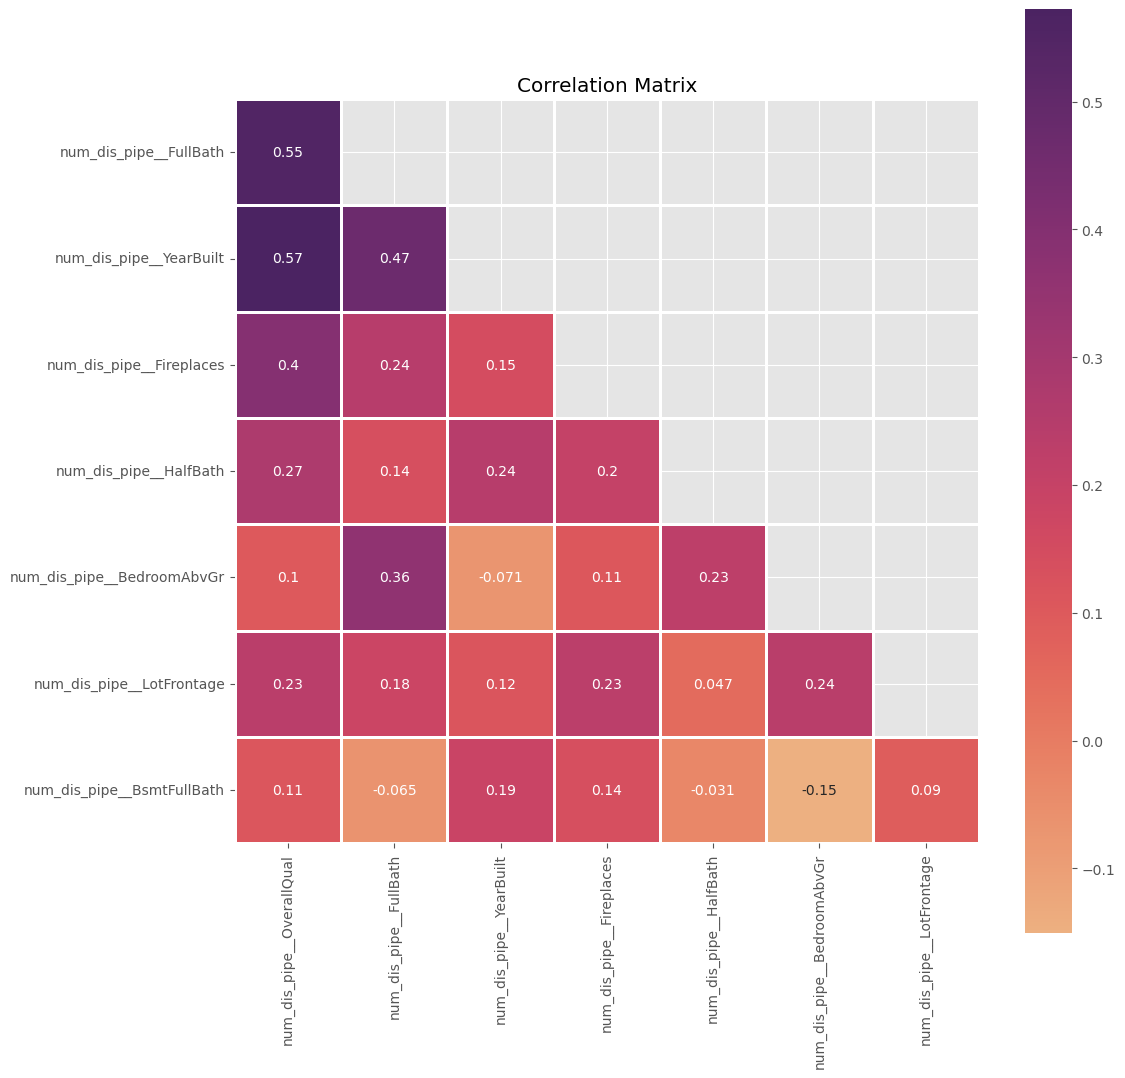

In [7]:
plot_numerical_data(X_train_trans.filter(regex='num_dis_pipe'), target=None)

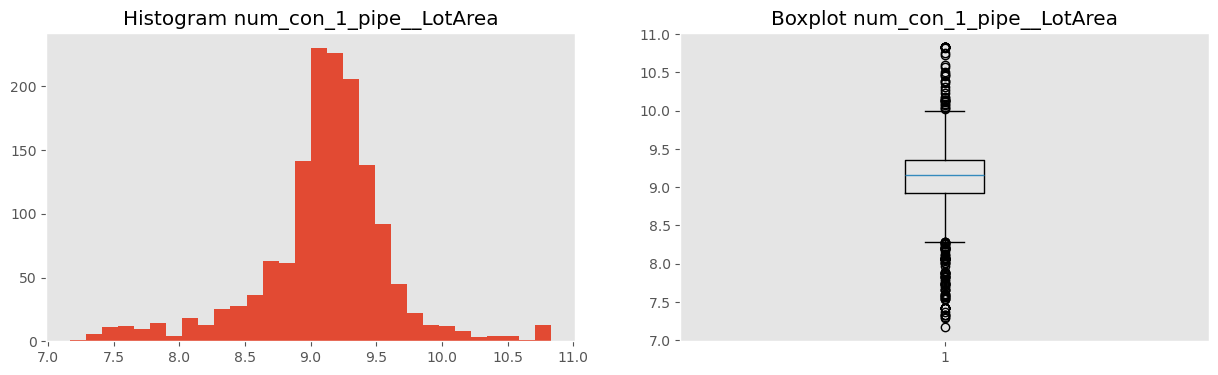

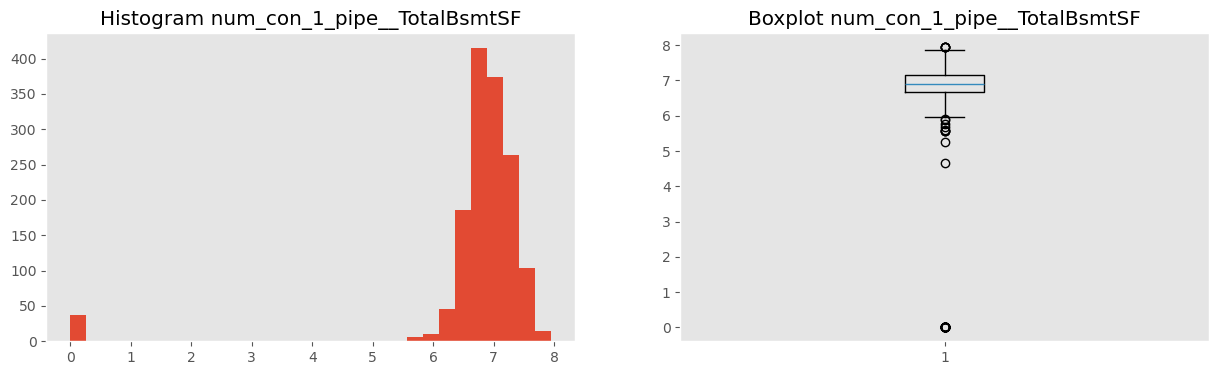

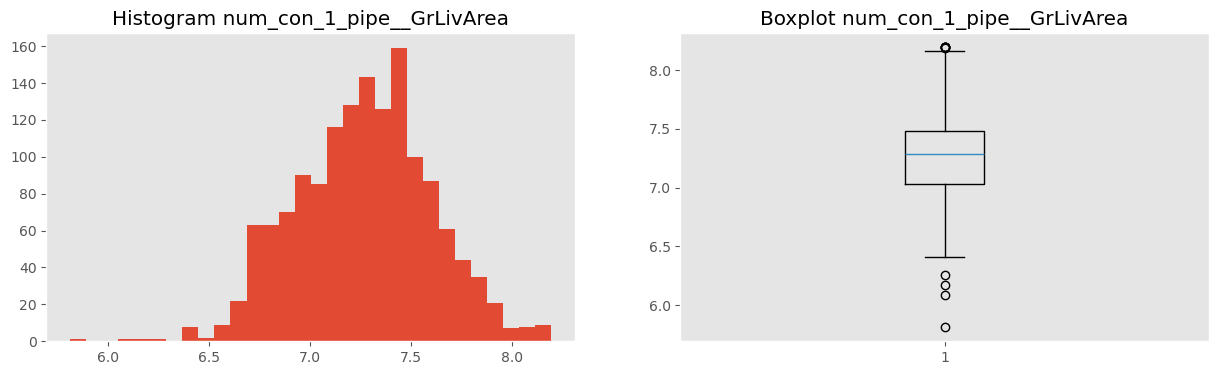

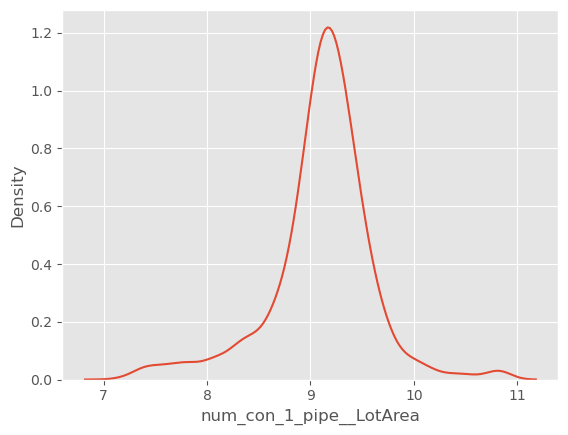

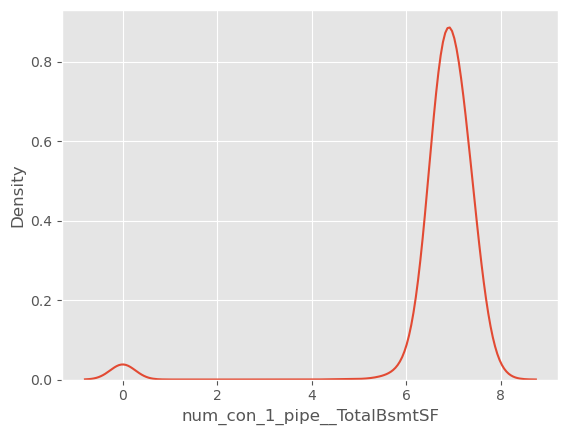

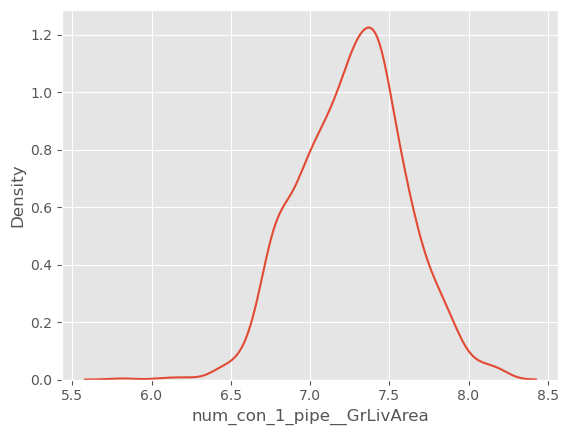

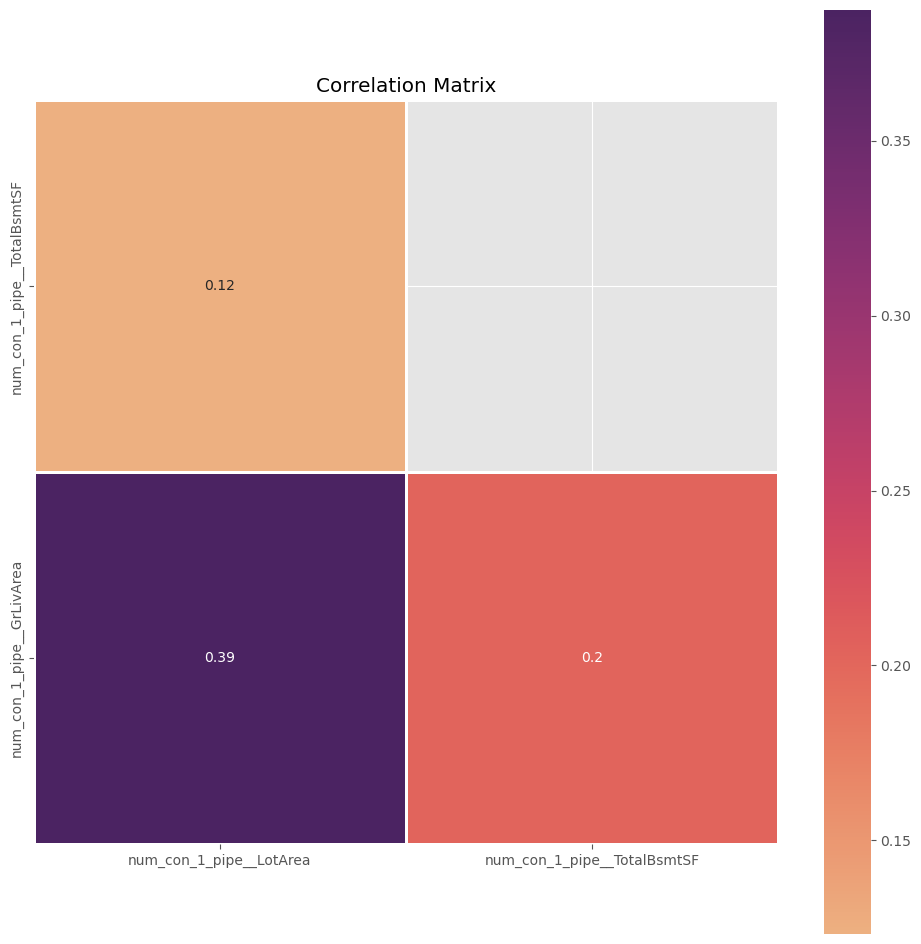

In [8]:
plot_numerical_data(X_train_trans.filter(regex='num_con_1_pipe'), target=None)

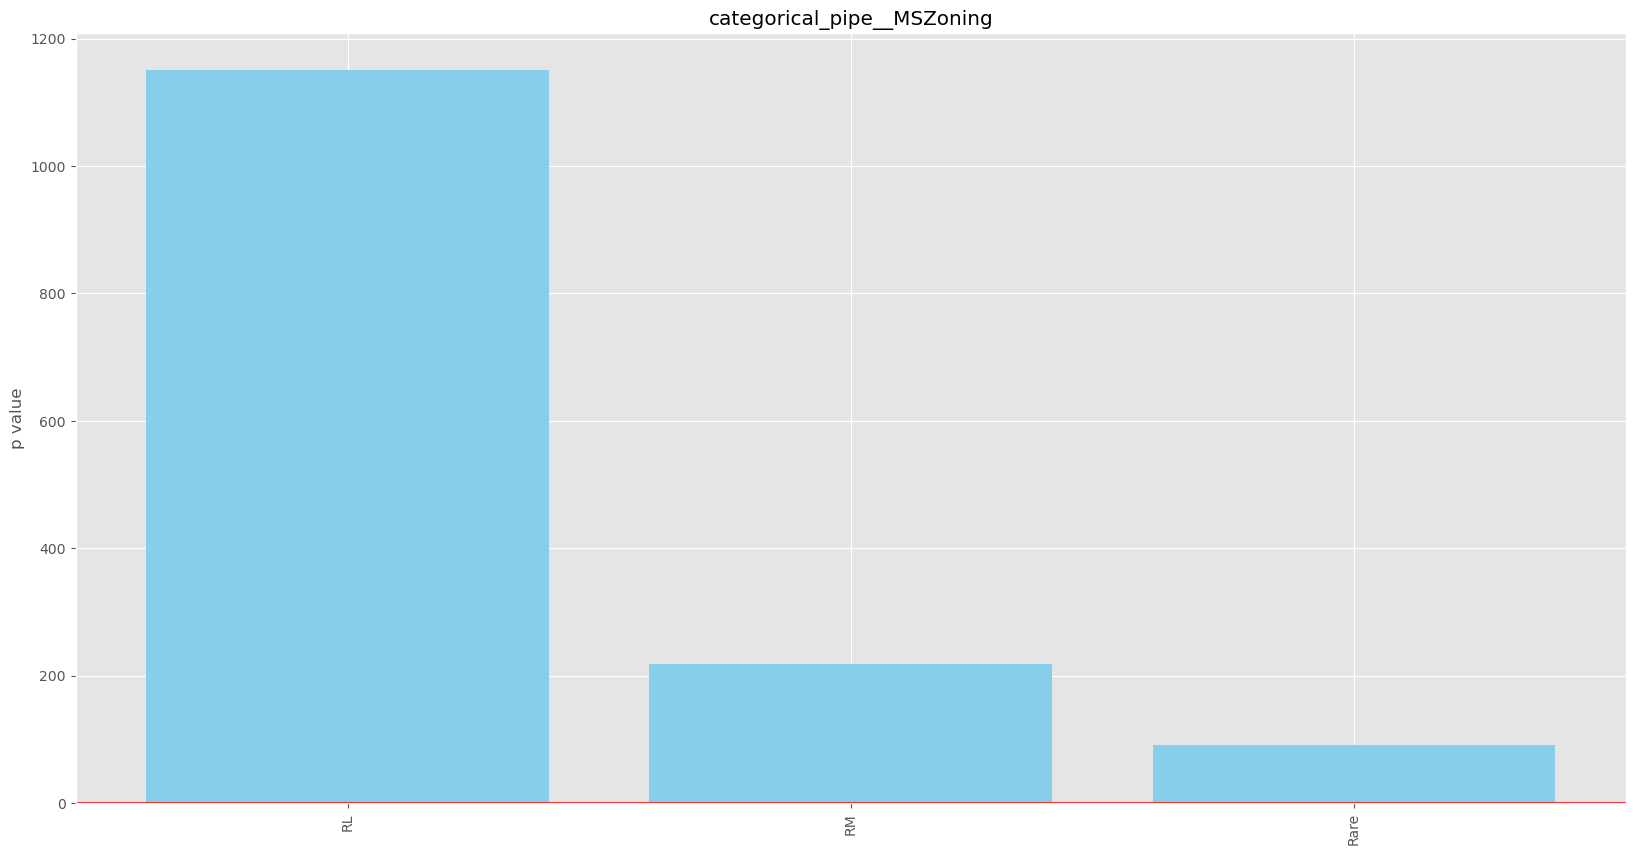

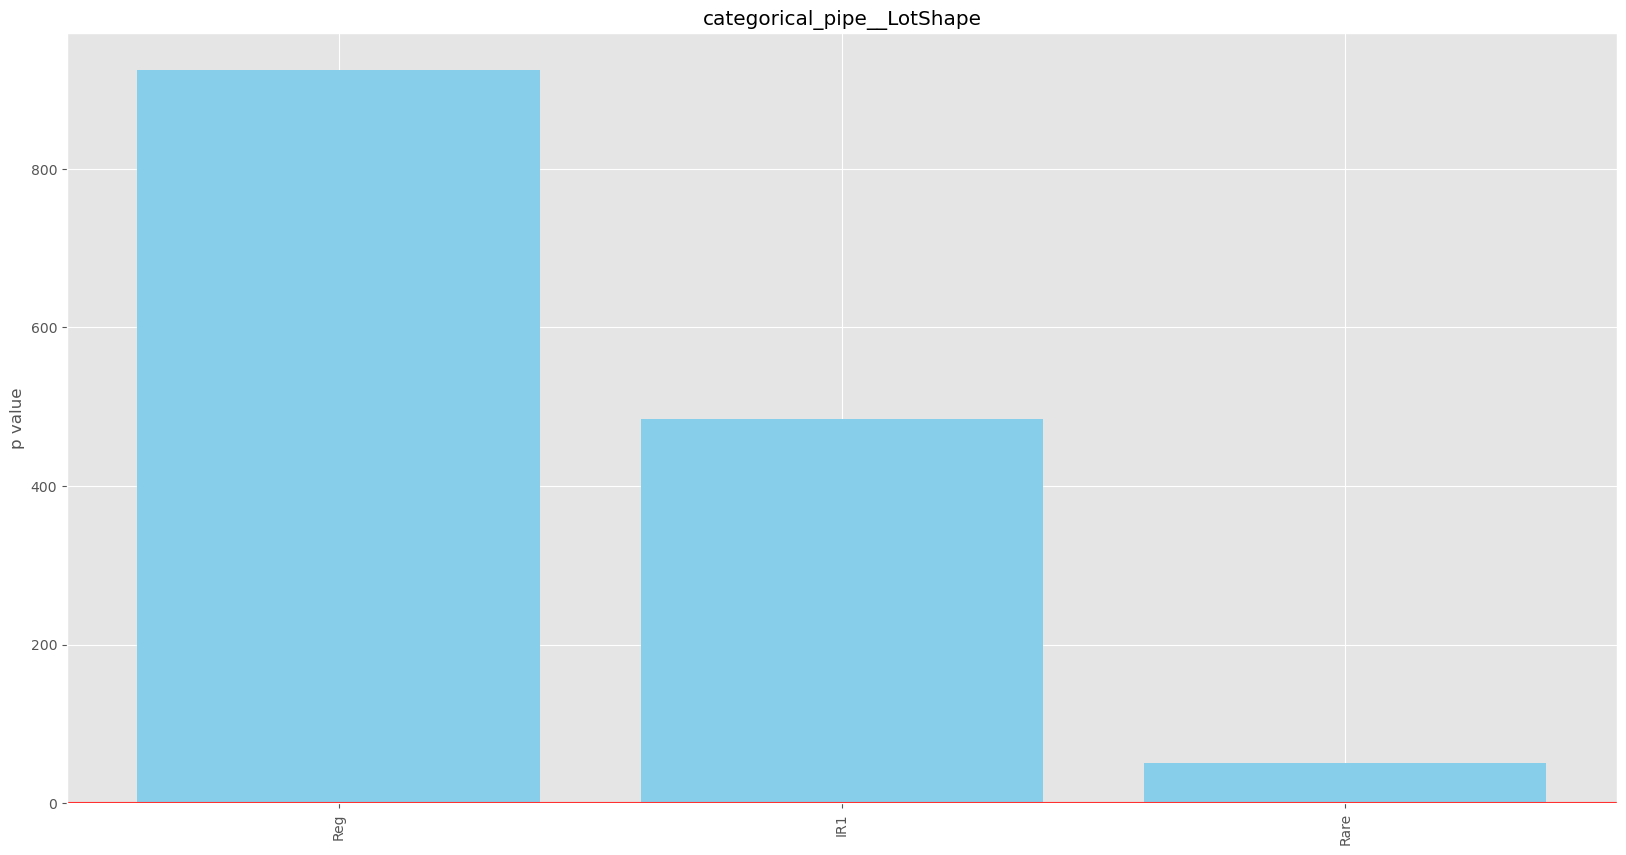

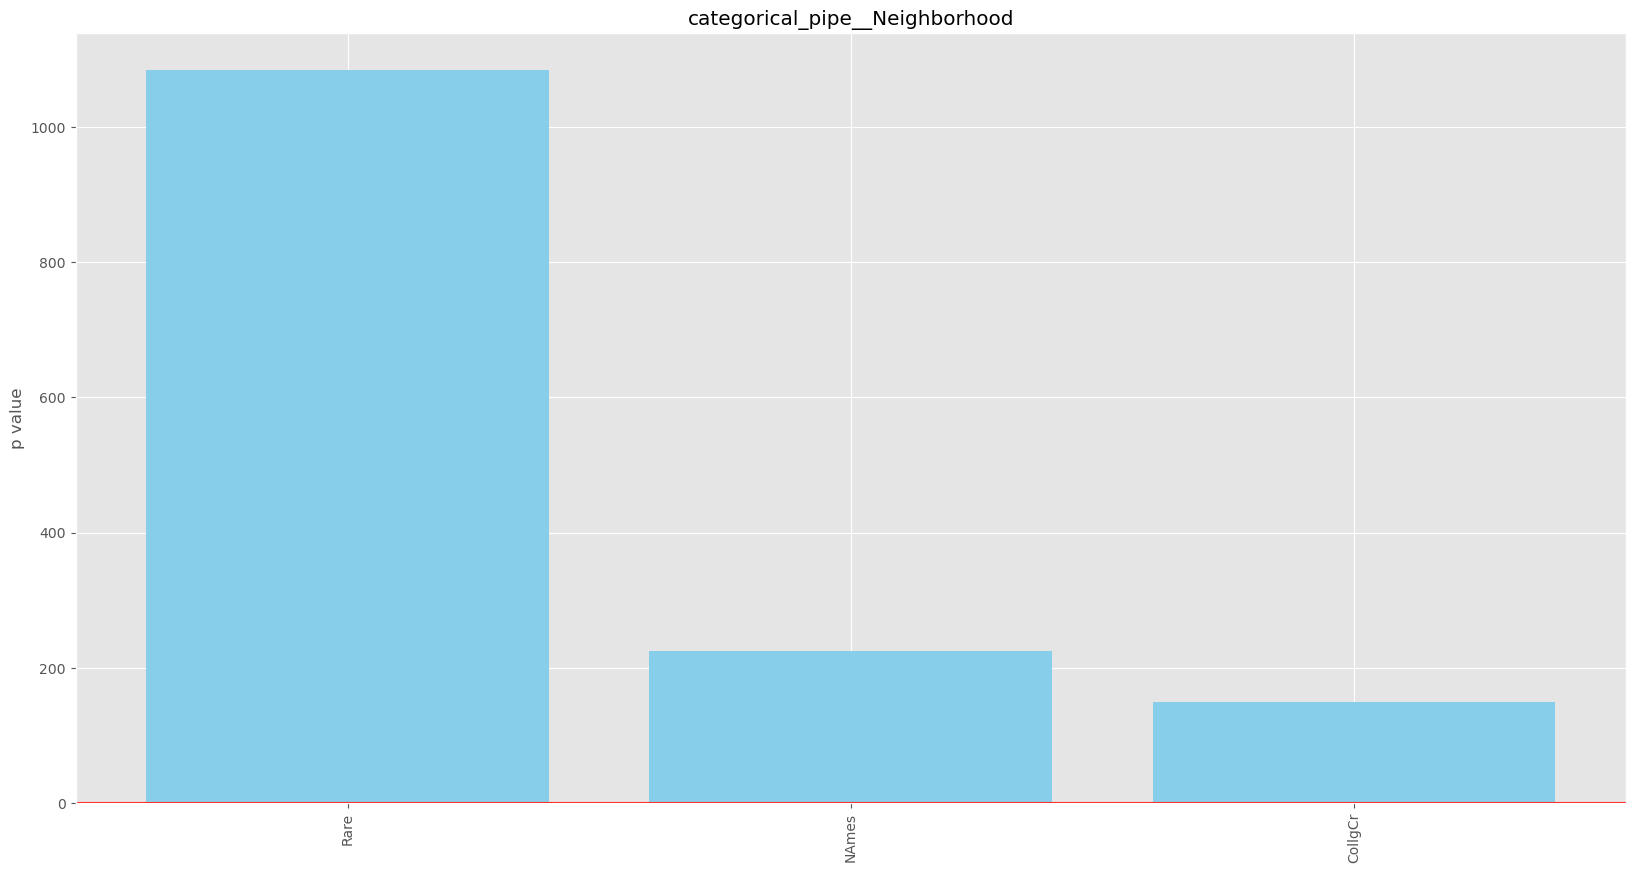

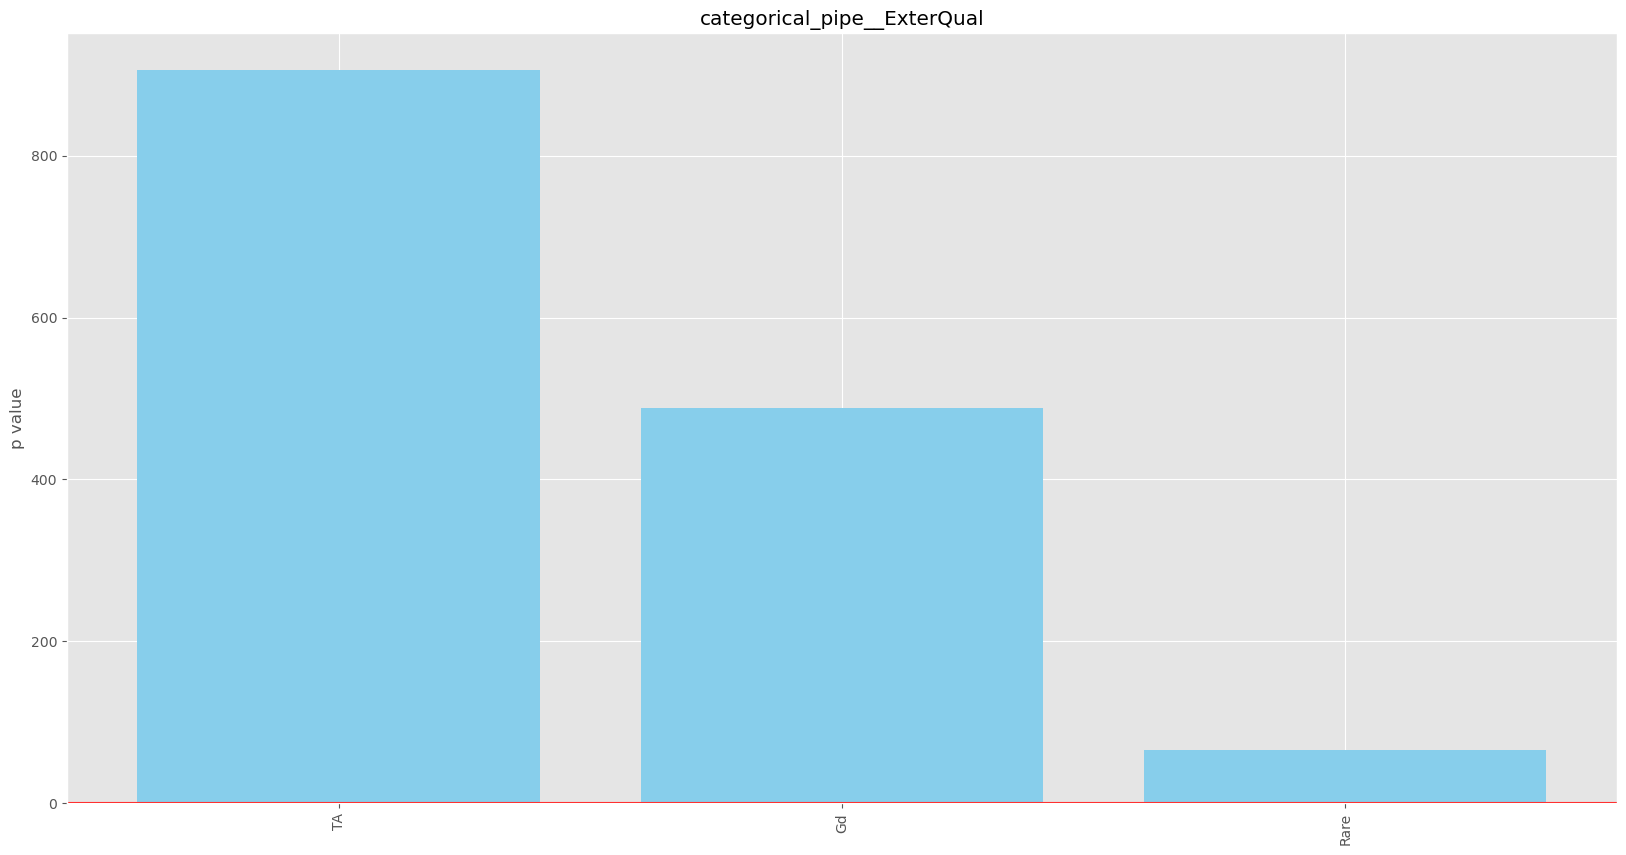

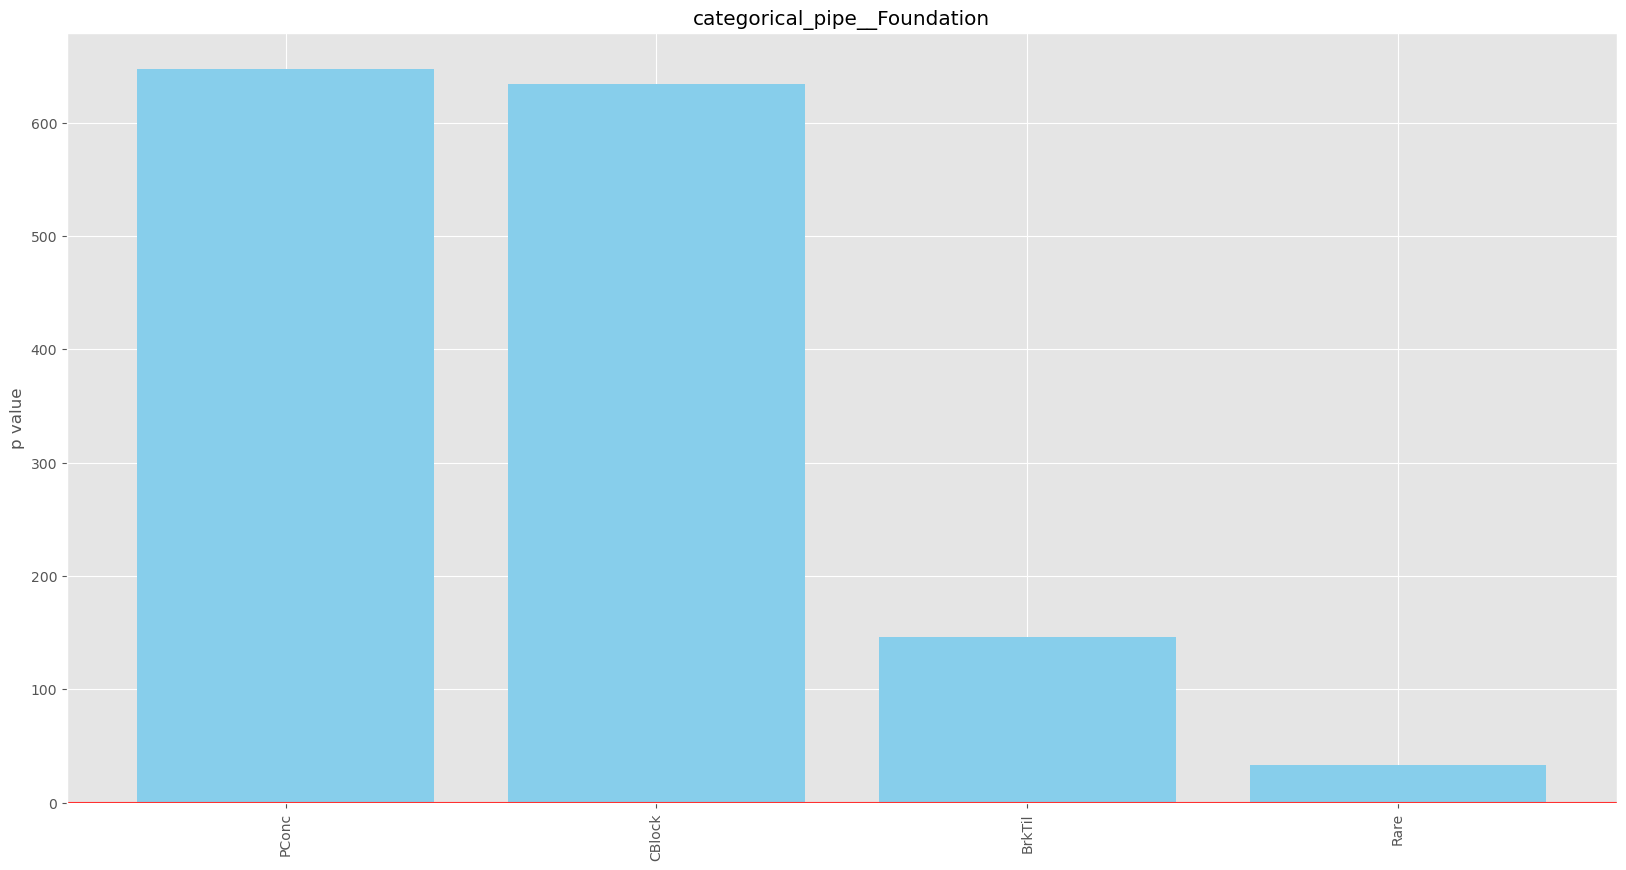

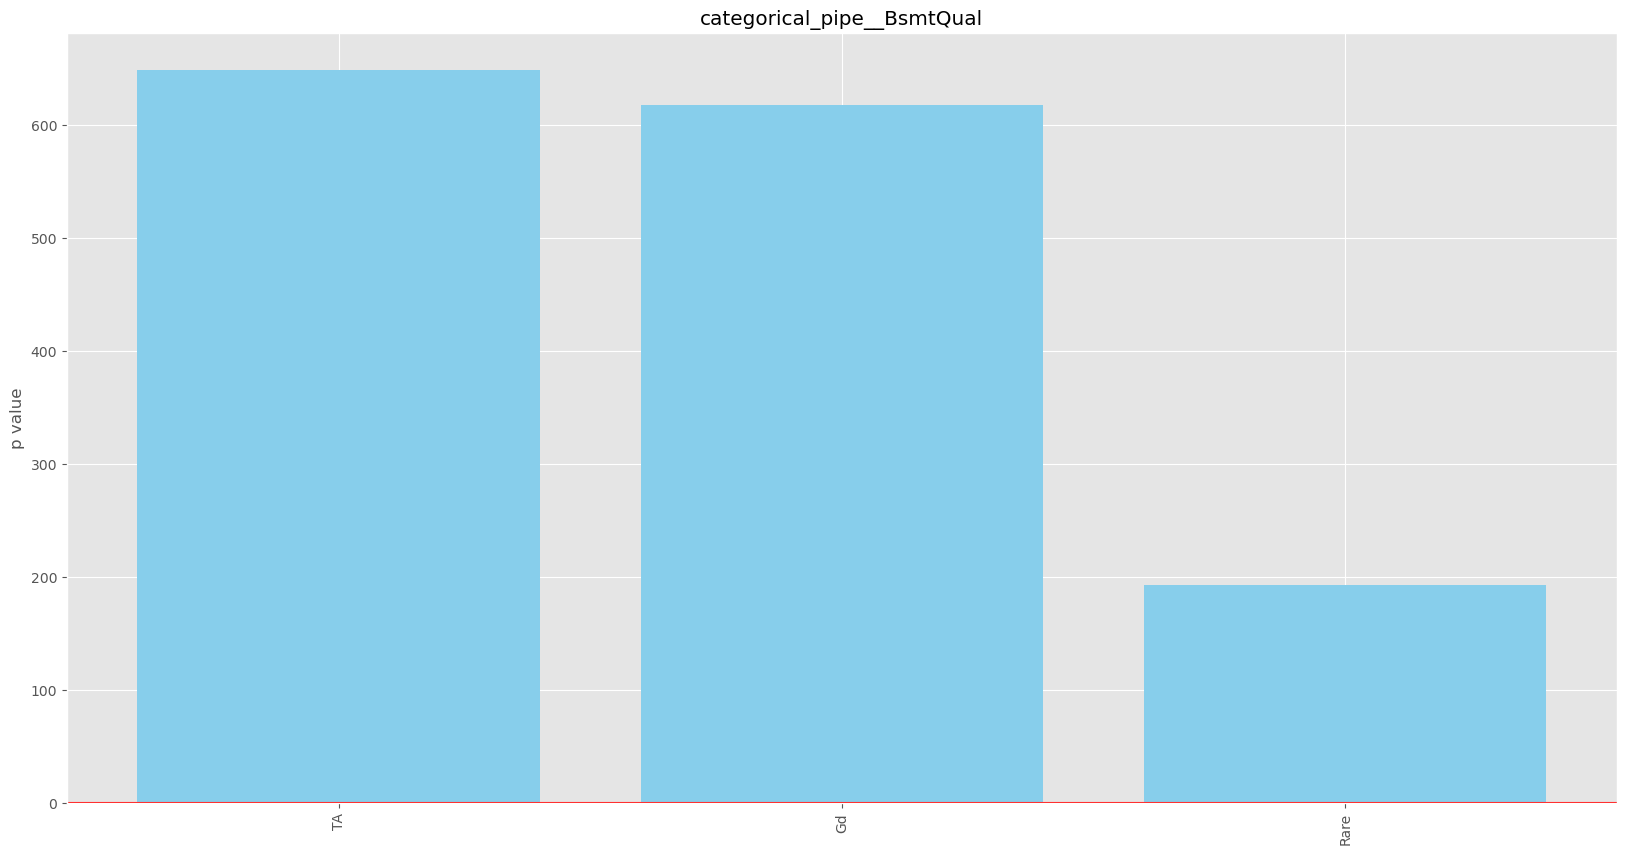

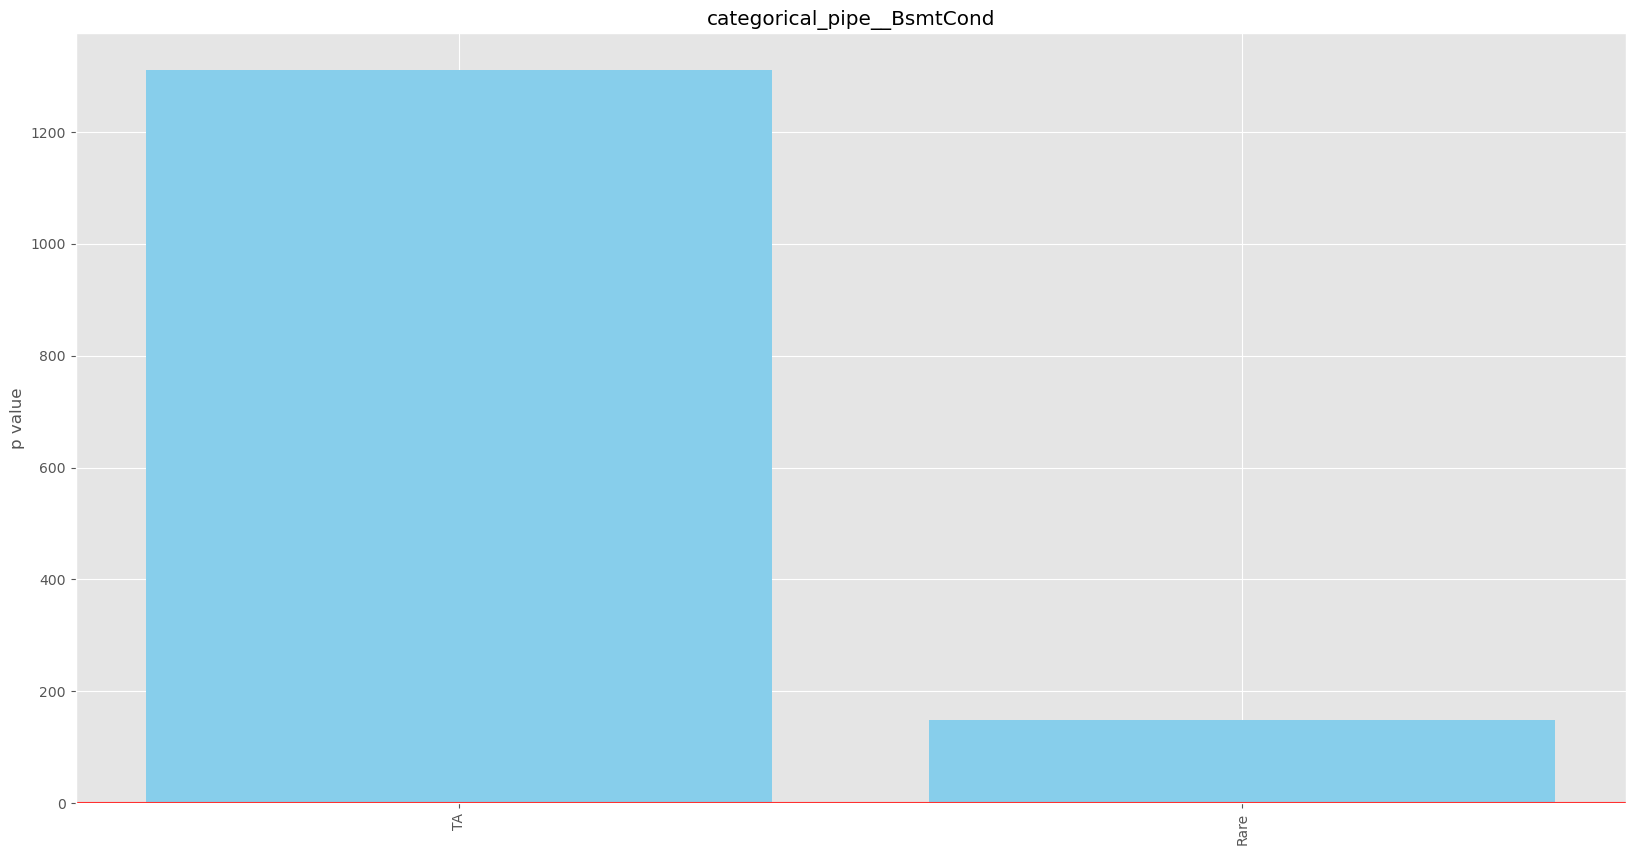

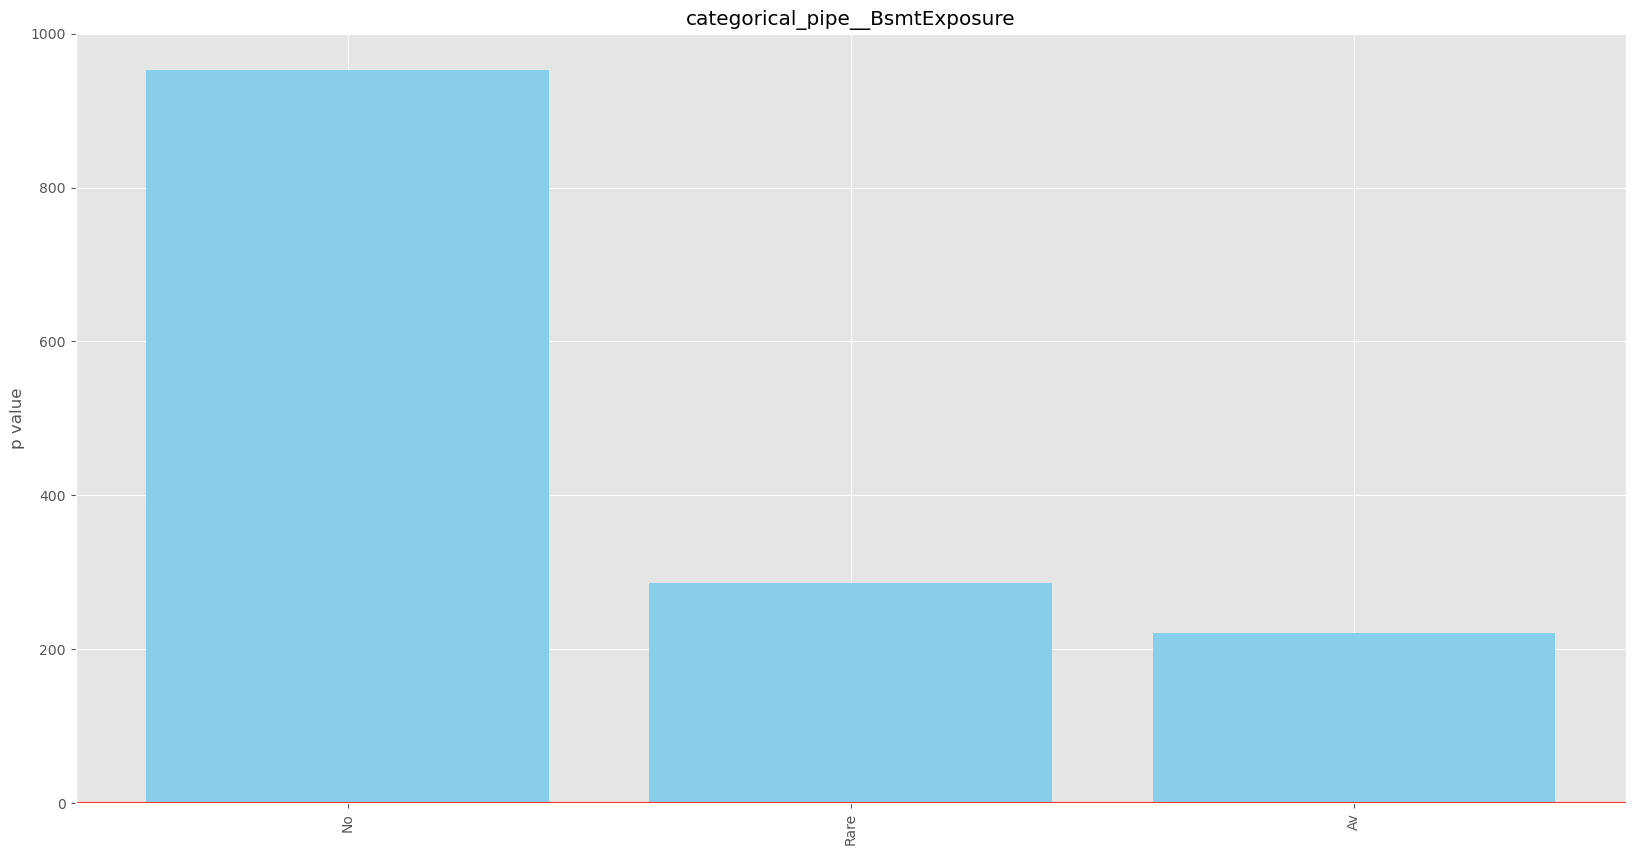

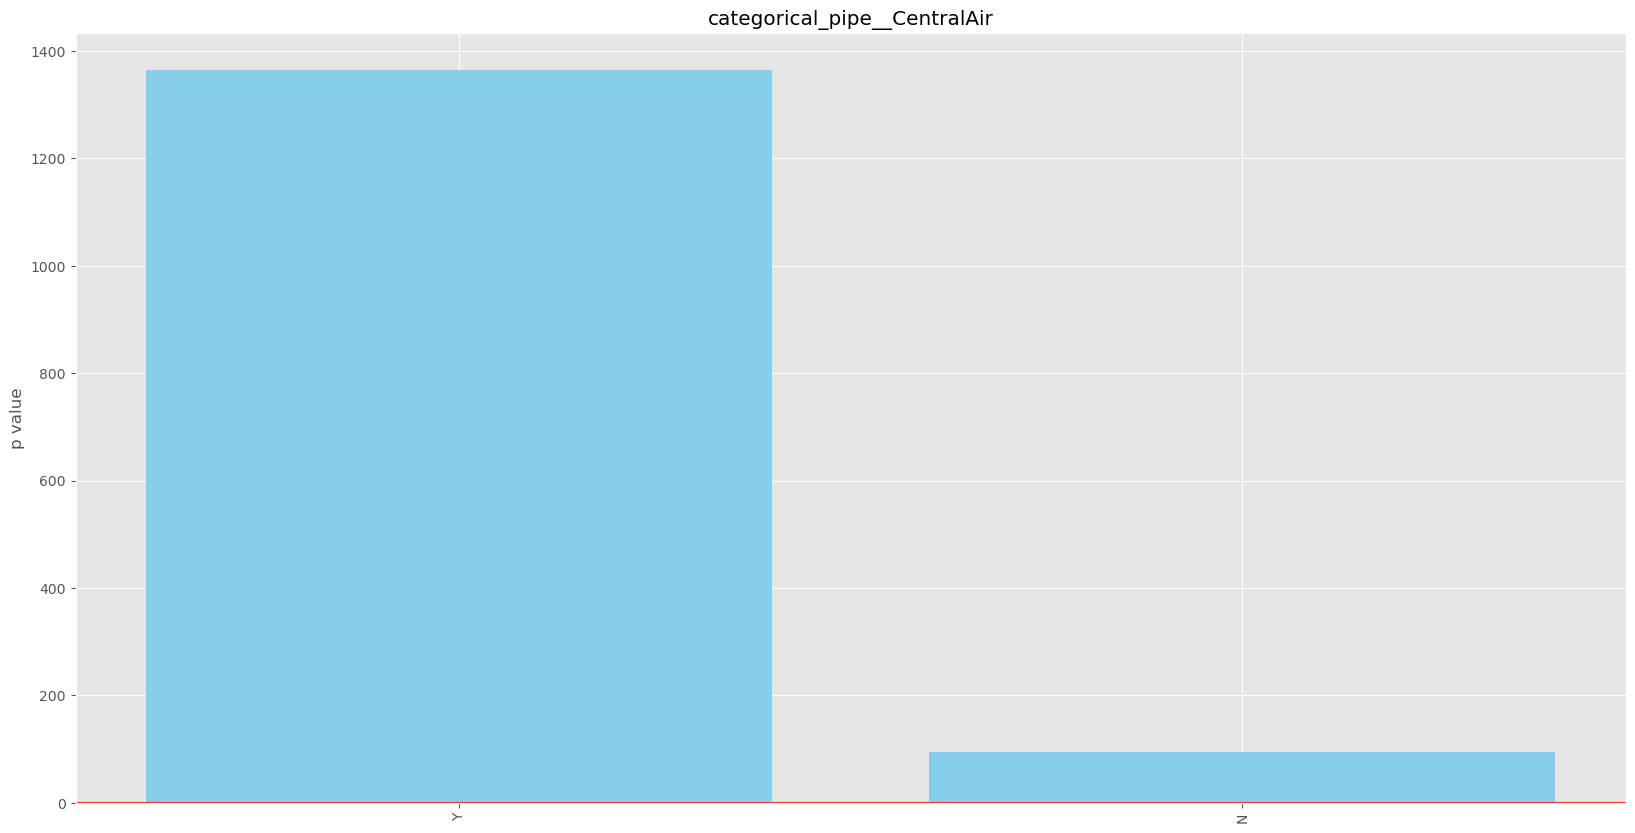

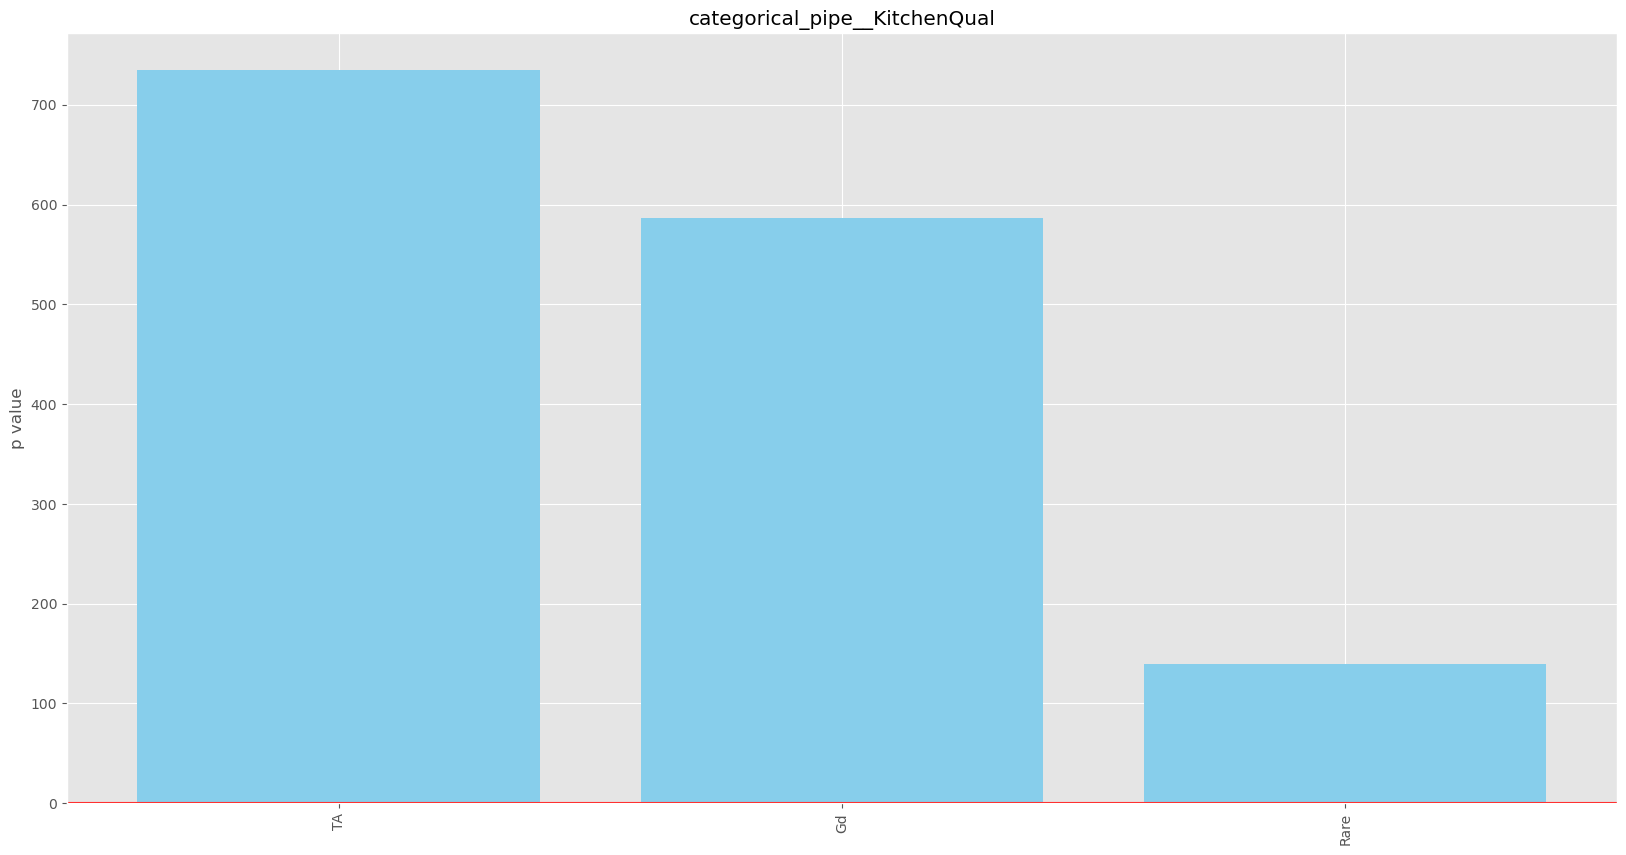

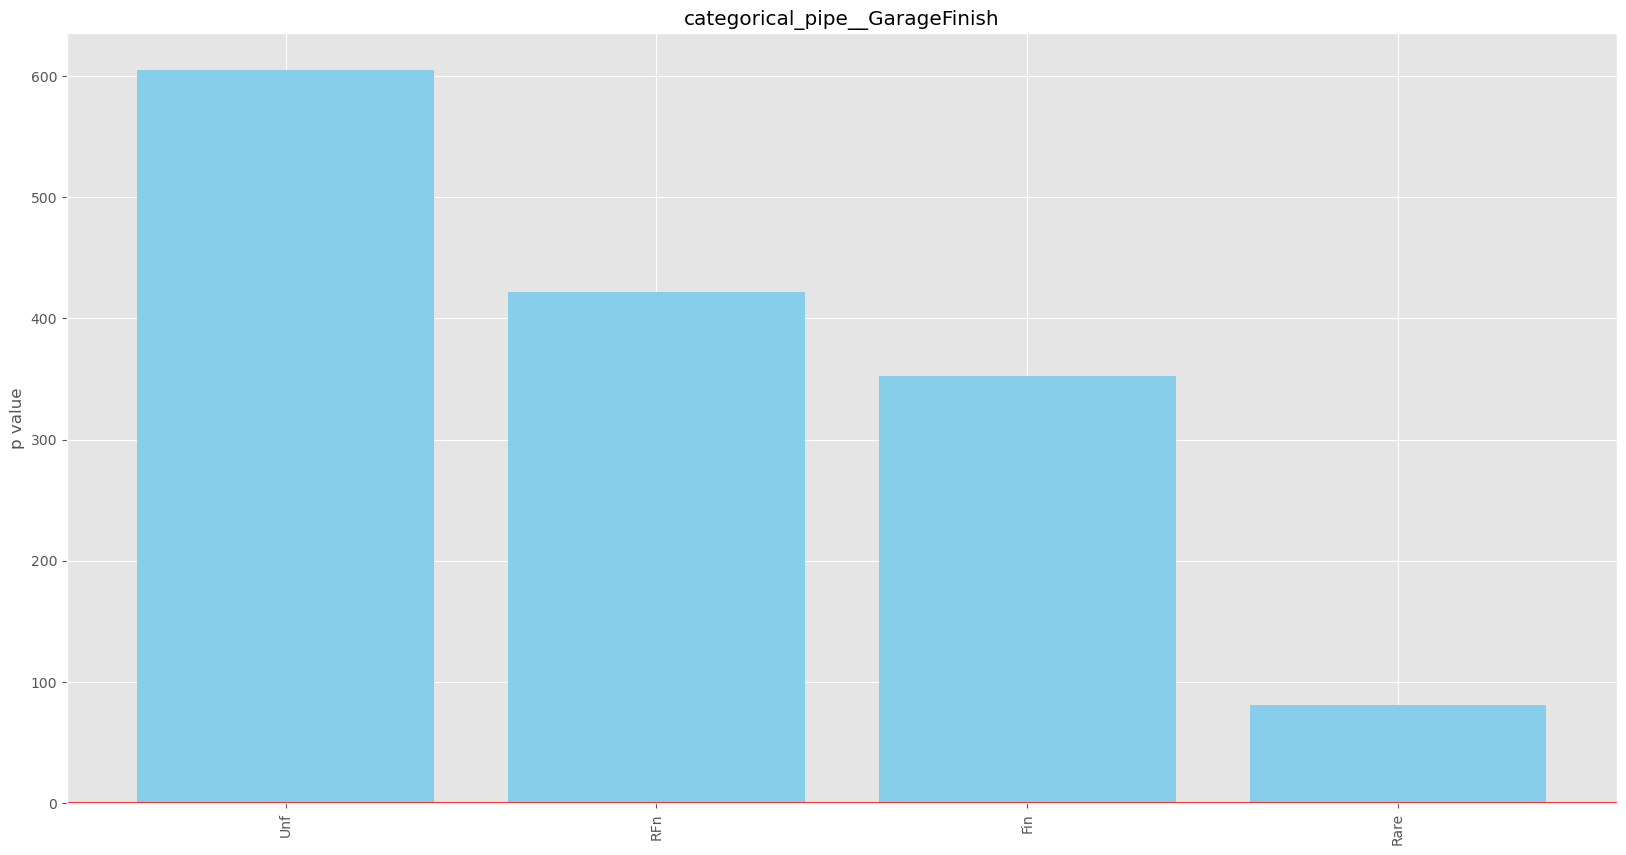

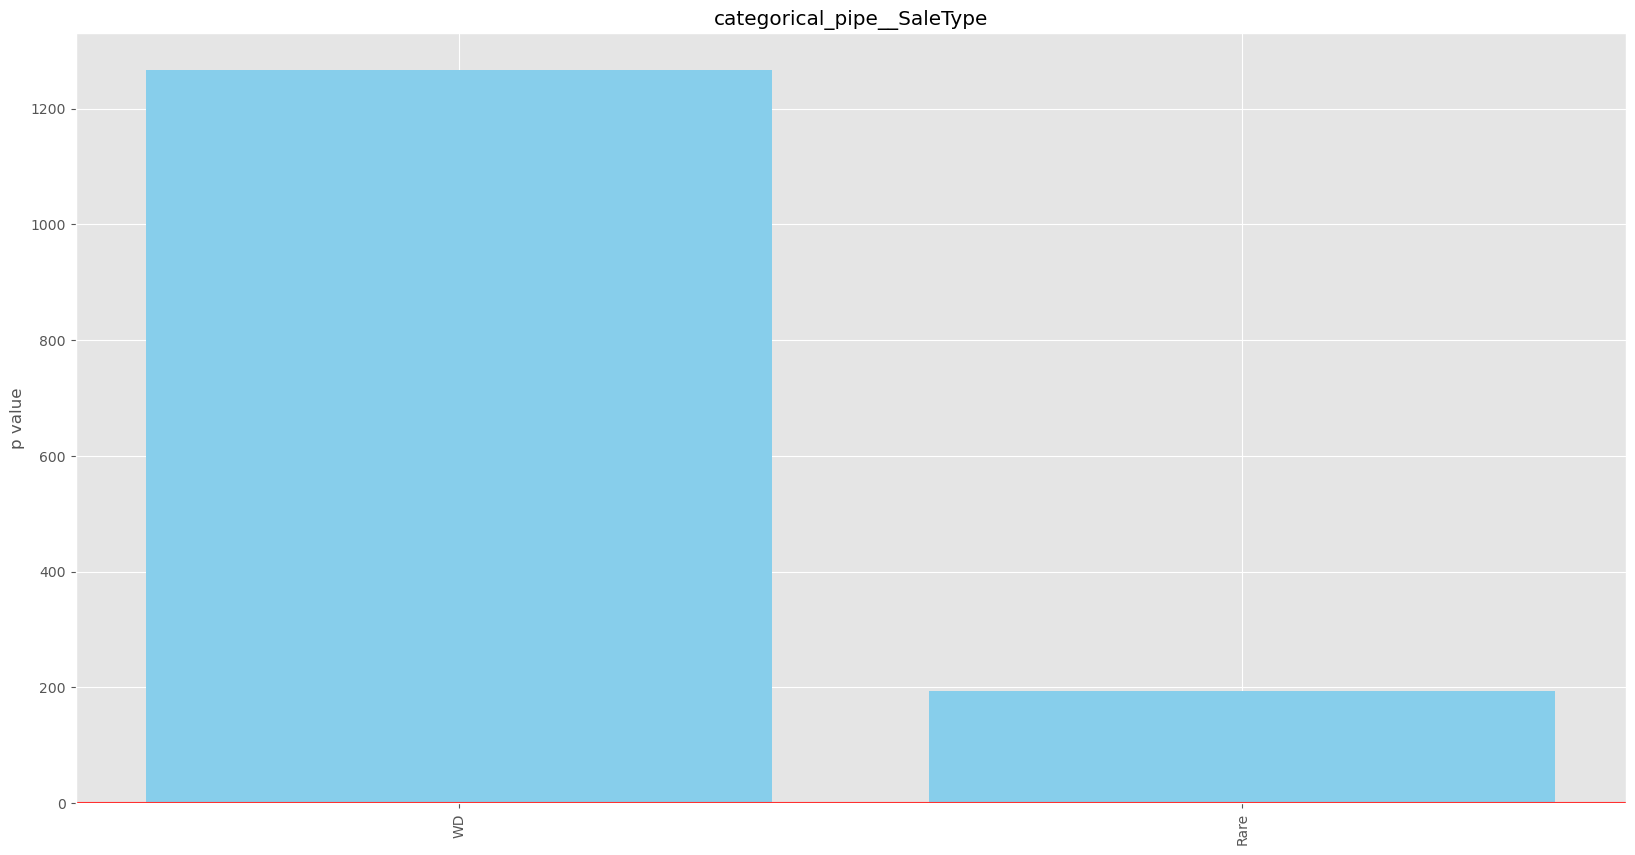

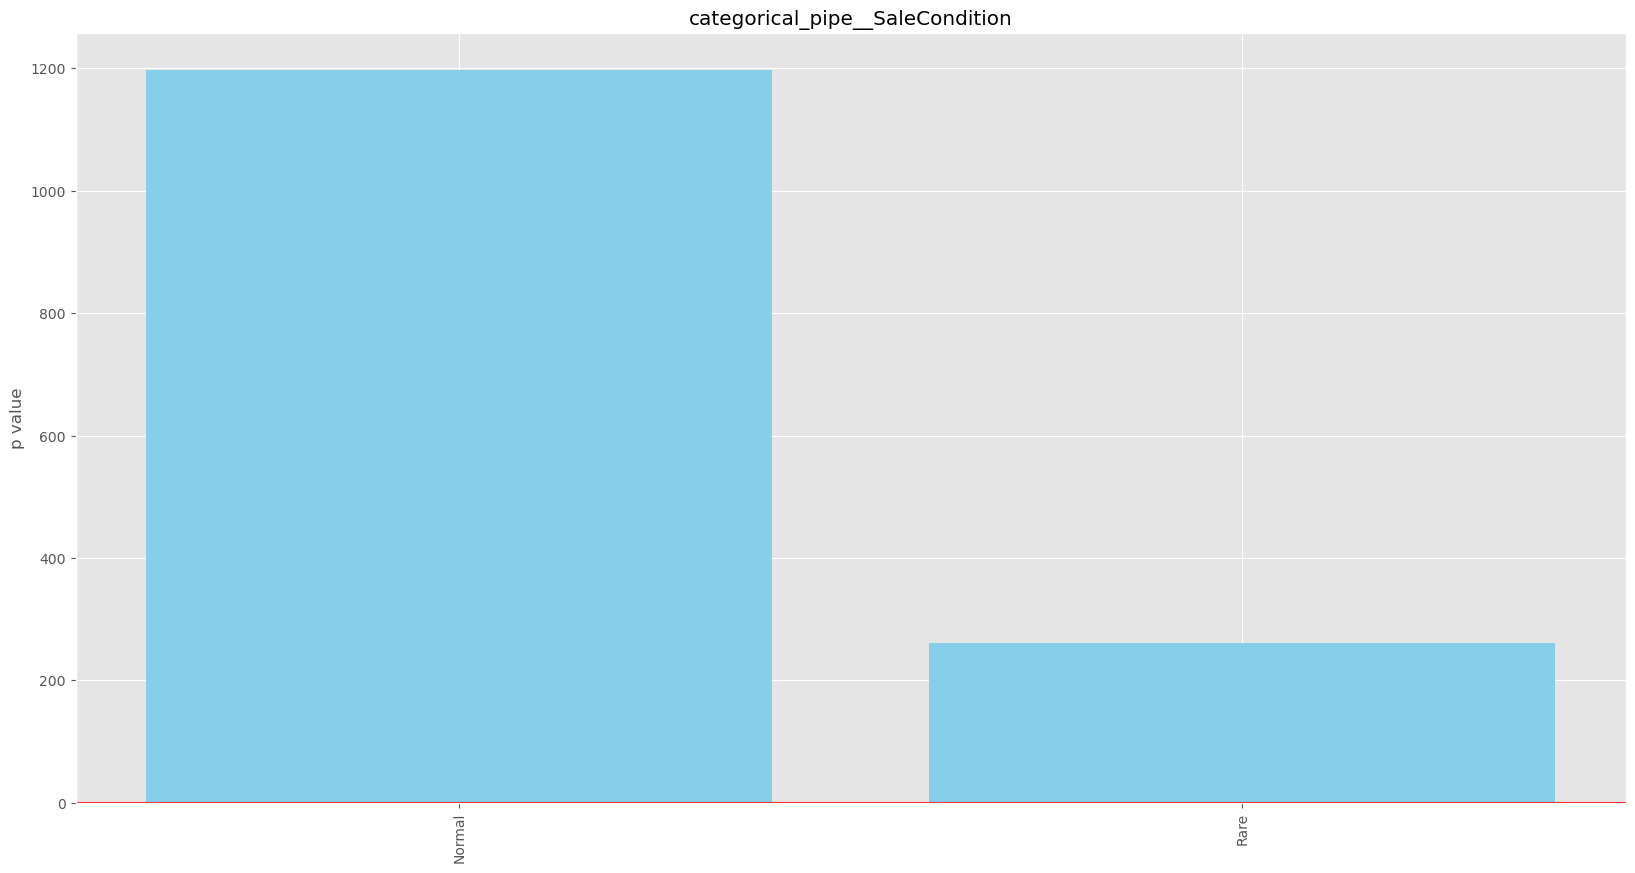

In [9]:
for col in X_train_trans.filter(like='categorical').columns:
    Bar_plot(X_train_trans[col].value_counts(), title=col)

# Univariate Feat Selection

In [10]:
feature_selection = FeatureSelectionOrchestrator()

In [11]:
constant_features = feature_selection.apply(
        "DropConstantFeatures", 
        X_train_trans, 
        y_train,
        threshold=0.90)

In [12]:
constant_features

['categorical_pipe__CentralAir']

In [13]:
duplicate_features = feature_selection.apply(
        "DropDuplicateFeatures", 
        X_train_trans,        
        y_train
        )

In [14]:
duplicate_features

set()

In [15]:
QuiSquare = feature_selection.apply(
        "QuiSquare", 
        X_train_trans.filter(like='categorical'), 
        y_train)

Feature: categorical_pipe__MSZoning
Feature: categorical_pipe__LotShape
Feature: categorical_pipe__Neighborhood
Feature: categorical_pipe__ExterQual
Feature: categorical_pipe__Foundation
Feature: categorical_pipe__BsmtQual
Feature: categorical_pipe__BsmtCond
Feature: categorical_pipe__BsmtExposure
Feature: categorical_pipe__CentralAir
Feature: categorical_pipe__KitchenQual
Feature: categorical_pipe__GarageFinish
Feature: categorical_pipe__SaleType
Feature: categorical_pipe__SaleCondition


In [16]:
# feature selection based on QuiSquare test
[i
    for i in QuiSquare.loc[QuiSquare < 0.05].index
]

['categorical_pipe__ExterQual',
 'categorical_pipe__KitchenQual',
 'categorical_pipe__BsmtQual',
 'categorical_pipe__SaleType',
 'categorical_pipe__Foundation',
 'categorical_pipe__GarageFinish',
 'categorical_pipe__SaleCondition',
 'categorical_pipe__CentralAir',
 'categorical_pipe__BsmtExposure',
 'categorical_pipe__MSZoning',
 'categorical_pipe__LotShape',
 'categorical_pipe__Neighborhood',
 'categorical_pipe__BsmtCond']

In [17]:
# feature selection based on QuiSquare test
[i
    for i in QuiSquare.loc[QuiSquare > 0.05].index
]

[]

In [18]:
X_train_trans.filter(like='num')

,num_con_1_pipe__LotArea,num_con_1_pipe__TotalBsmtSF,num_con_1_pipe__GrLivArea,num_con_2_pipe__MasVnrArea,num_con_2_pipe__BsmtFinSF1,num_con_2_pipe__2ndFlrSF,num_con_2_pipe__WoodDeckSF,num_con_2_pipe__OpenPorchSF,num_con_2_pipe__GarageArea,num_con_2_pipe__BsmtUnfSF,num_dis_pipe__OverallQual,num_dis_pipe__FullBath,num_dis_pipe__YearBuilt,num_dis_pipe__Fireplaces,num_dis_pipe__HalfBath,num_dis_pipe__BedroomAbvGr,num_dis_pipe__LotFrontage,num_dis_pipe__BsmtFullBath
0,9.041922,6.753438,7.444249,7,7,8,0,6,8,6,7,2,2003,0,1,3,65.0,1
1,9.169518,7.141245,7.140453,0,7,0,8,0,8,7,6,2,1976,1,0,3,80.0,0
2,9.328123,6.825460,7.487734,6,7,8,0,5,8,7,7,2,2001,1,1,3,68.0,1
3,9.164296,6.629363,7.448334,0,6,8,0,5,8,8,7,1,1915,1,0,3,60.0,1
4,9.565214,7.044033,7.695303,7,7,9,7,7,9,7,8,2,2000,1,1,4,84.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,8.976768,6.860664,7.406711,0,0,8,0,5,8,8,6,2,1999,1,1,3,62.0,0
1456,9.486076,7.341484,7.636752,6,7,0,8,0,8,8,6,2,1978,2,0,3,85.0,1
1457,9.109636,7.050123,7.757906,0,6,9,0,6,7,8,7,2,1941,2,0,4,66.0,0
1458,9.181632,6.983790,6.982863,0,4,0,8,0,7,0,5,1,1950,0,0,2,68.0,1


In [19]:
Anova = feature_selection.apply(
        "Anova",
        X_train_trans.filter(like='num'),
        y_train.values)

In [20]:
mi = feature_selection.apply(
        "MutualInformationClassif", 
        X_train_trans.filter(like='num'), 
        y_train)
    
corr = feature_selection.apply(
        "PearsonCorrelation", 
        X_train_trans.filter(like='num'), 
        y_train)

In [21]:
[i.replace("numerical_dis_pipe__", "")
    for i in 
    Anova.loc[Anova > 0.05].index
]

['num_con_2_pipe__BsmtUnfSF']

In [22]:
[i.replace("num_dis_pipe__", "")
    for i in 
    Anova.loc[Anova < 0.05].index
]

['OverallQual',
 'num_con_1_pipe__GrLivArea',
 'FullBath',
 'YearBuilt',
 'num_con_1_pipe__TotalBsmtSF',
 'Fireplaces',
 'num_con_2_pipe__OpenPorchSF',
 'num_con_2_pipe__GarageArea',
 'num_con_2_pipe__MasVnrArea',
 'HalfBath',
 'num_con_2_pipe__BsmtFinSF1',
 'num_con_1_pipe__LotArea',
 'num_con_2_pipe__WoodDeckSF',
 'BedroomAbvGr',
 'LotFrontage',
 'num_con_2_pipe__2ndFlrSF',
 'BsmtFullBath']

In [23]:
[i.replace("num_con_pipe__", "")
    for i in 
    Anova.loc[Anova < 0.05].index
]

['num_dis_pipe__OverallQual',
 'num_con_1_pipe__GrLivArea',
 'num_dis_pipe__FullBath',
 'num_dis_pipe__YearBuilt',
 'num_con_1_pipe__TotalBsmtSF',
 'num_dis_pipe__Fireplaces',
 'num_con_2_pipe__OpenPorchSF',
 'num_con_2_pipe__GarageArea',
 'num_con_2_pipe__MasVnrArea',
 'num_dis_pipe__HalfBath',
 'num_con_2_pipe__BsmtFinSF1',
 'num_con_1_pipe__LotArea',
 'num_con_2_pipe__WoodDeckSF',
 'num_dis_pipe__BedroomAbvGr',
 'num_dis_pipe__LotFrontage',
 'num_con_2_pipe__2ndFlrSF',
 'num_dis_pipe__BsmtFullBath']

In [24]:
smart_corr = feature_selection.apply(
        "SmartCorrelatedSelection",
        X_train_trans.filter(like='num'),
        y_train)

In [25]:
smart_corr

{'corr_feature': [], 'corr_2_drop': []}

In [26]:
mrmr = feature_selection.apply(
        "MRMR",        
        X_train_trans,
        y_train,
        method="MIQ"
        )

In [27]:
mrmr['features_to_drop']

['num_con_1_pipe__LotArea',
 'num_con_1_pipe__TotalBsmtSF',
 'num_con_1_pipe__GrLivArea',
 'num_con_2_pipe__MasVnrArea',
 'num_con_2_pipe__BsmtFinSF1',
 'num_con_2_pipe__2ndFlrSF',
 'num_con_2_pipe__WoodDeckSF',
 'num_con_2_pipe__OpenPorchSF',
 'num_con_2_pipe__GarageArea',
 'num_con_2_pipe__BsmtUnfSF',
 'num_dis_pipe__OverallQual',
 'num_dis_pipe__YearBuilt',
 'num_dis_pipe__HalfBath',
 'num_dis_pipe__BedroomAbvGr',
 'num_dis_pipe__LotFrontage']

In [28]:
mrmr['relevance']

array([0.14272092, 0.22872353, 0.38771906, 0.15122787, 0.32882605,
       0.27971223, 0.15483631, 0.27848503, 1.77428322, 0.39491383,
       0.98903724, 2.06113476, 0.28830672, 0.6955868 , 0.45582091,
       1.03718805, 0.15049626, 0.40665663])